In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('optimal_ranges_combo.csv')

df = df.set_index("Unnamed: 0")

labels = df.columns.tolist()
df = df.loc[labels, labels]  

data = df.fillna("").values.tolist()

In [5]:
def get_range_width(cell):
    try:
        nums = eval(cell)
        return nums[1] - nums[0]
    except:
        return np.nan

In [6]:
value_matrix = np.array([
    [get_range_width(cell) for cell in row]
    for row in data
])

/var/folders/85/rzkn78t10p72g2_nfq5ytx3w0000gn/T/ipykernel_14554/2410129434.py:15: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((i-.5, i-.5), 1, 1, fill=True, color='green', edgecolor='black'))


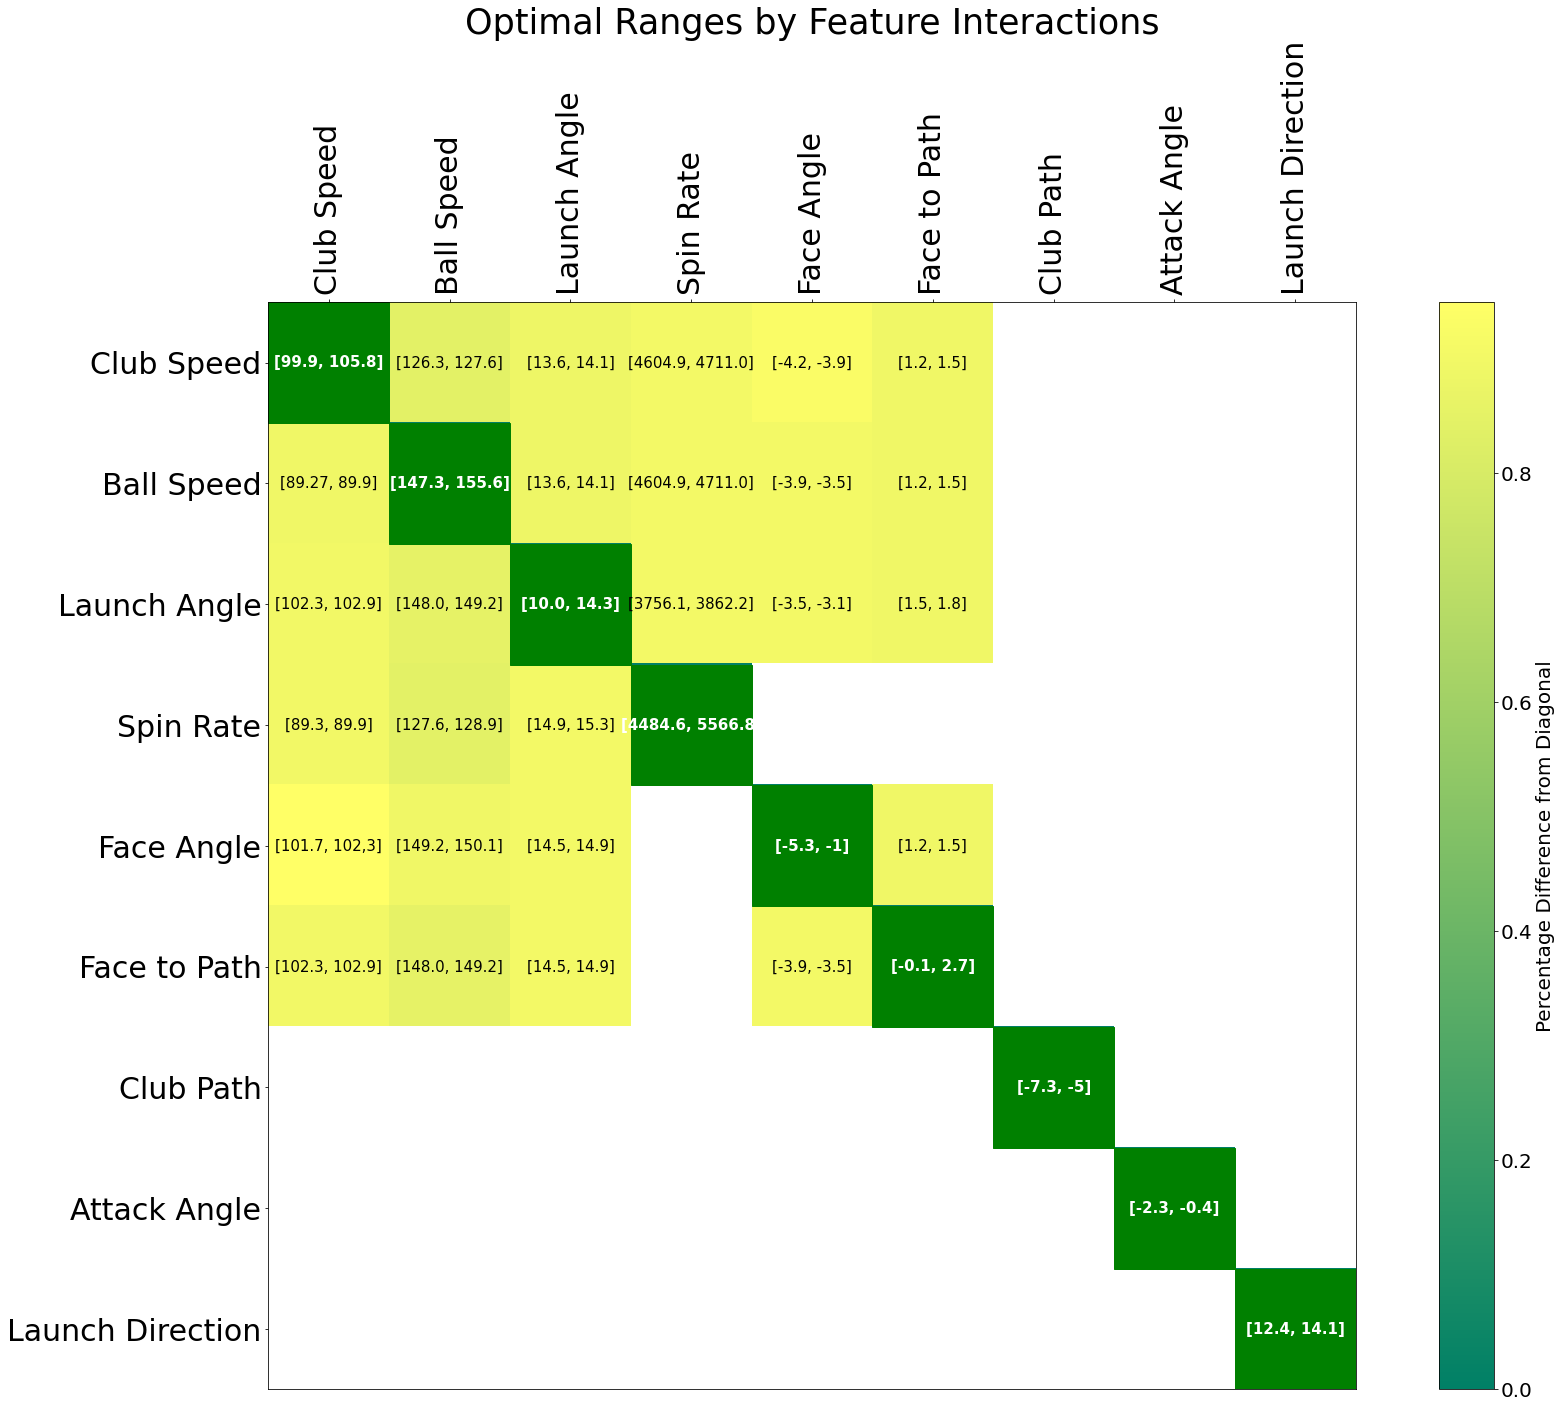

In [51]:
fig, ax = plt.subplots(figsize=(30, 20))
diag = np.diag(value_matrix)
diff_from_diag = np.abs(value_matrix - diag[np.newaxis, :])
percent_diff = np.abs(value_matrix - diag[np.newaxis, :]) / np.abs(diag[np.newaxis, :])

masked_array = np.ma.masked_invalid(percent_diff)

c = ax.imshow(masked_array, cmap='summer')

for i in range(len(labels)):
    for j in range(len(labels)):
        if data[i][j] != "":
            if i == j:
                ax.text(j, i, data[i][j], ha='center', va='center', color = 'white', fontsize=15, weight='bold')
                ax.add_patch(plt.Rectangle((i-.5, i-.5), 1, 1, fill=True, color='green', edgecolor='black'))
            else:
                ax.text(j, i, data[i][j], ha='center', va='center', fontsize=15)
    

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, fontsize=30, rotation = 90)
ax.set_yticklabels(labels, fontsize=30)
ax.xaxis.tick_top()

plt.title("Optimal Ranges by Feature Interactions", fontsize=35)

cbar = fig.colorbar(c, ax=ax)
cbar.ax.tick_params(labelsize=20)  
cbar.set_label("Percentage Difference from Diagonal", fontsize = 20)  

plt.show()